In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# 数据目录
data_dir = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-kv-block-issue-sharegpt")

# 定义需要读取的配置
request_rates = [0.5, 1, 2]
block_sizes = [16, 32, 64, 128, 256, 512]

def parse_benchmark_log(log_path):
    """从benchmark.log末尾解析指标"""
    with open(log_path, 'r') as f:
        content = f.read()
    
    metrics = {}
    patterns = {
        'ttft_mean': r'Mean TTFT \(ms\):\s+([\d.]+)',
        'ttft_median': r'Median TTFT \(ms\):\s+([\d.]+)',
        'ttft_p99': r'P99 TTFT \(ms\):\s+([\d.]+)',
        'tpot_mean': r'Mean TPOT \(ms\):\s+([\d.]+)',
        'tpot_median': r'Median TPOT \(ms\):\s+([\d.]+)',
        'tpot_p99': r'P99 TPOT \(ms\):\s+([\d.]+)',
        'throughput': r'Output token throughput \(tok/s\):\s+([\d.]+)',
    }
    
    for key, pattern in patterns.items():
        match = re.search(pattern, content)
        metrics[key] = float(match.group(1)) if match else np.nan
    
    return metrics

# 存储汇总数据
results = []

for rr in request_rates:
    for blk in block_sizes:
        dir_pattern = f"test-{{kernel=direct}}-{{pp=36-44}}-{{rr={rr}}}-{{mig=0}}-{{in=512}}-{{out=128}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}-{{blk={blk}}}"
        dir_path = data_dir / dir_pattern
        log_file = dir_path / "benchmark.log"
        
        if log_file.exists():
            metrics = parse_benchmark_log(log_file)
            results.append({
                'request_rate': rr,
                'block_size': blk,
                **metrics
            })

results_df = pd.DataFrame(results)
print(results_df.to_string())


    request_rate  block_size  ttft_mean  ttft_median  ttft_p99  tpot_mean  tpot_median  tpot_p99  throughput
0            0.5          16     285.09       219.65    669.10     144.21       144.47    166.21       84.94
1            0.5          32     291.54       231.82    667.95     109.17       109.56    138.95       89.34
2            0.5          64     285.08       217.20    669.69     115.97       108.60    149.22       84.72
3            0.5         128     280.92       212.34    660.81     142.57       143.69    157.77       84.88
4            0.5         256     288.24       230.28    780.75     105.51       105.91    117.71       89.32
5            0.5         512     285.21       233.08    665.23     106.13       106.27    122.34       89.63
6            1.0          16     303.98       231.96    716.82     155.26       156.87    185.87      139.94
7            1.0          32     298.54       232.83    678.77     145.87       148.63    175.40      140.48
8            1.0   

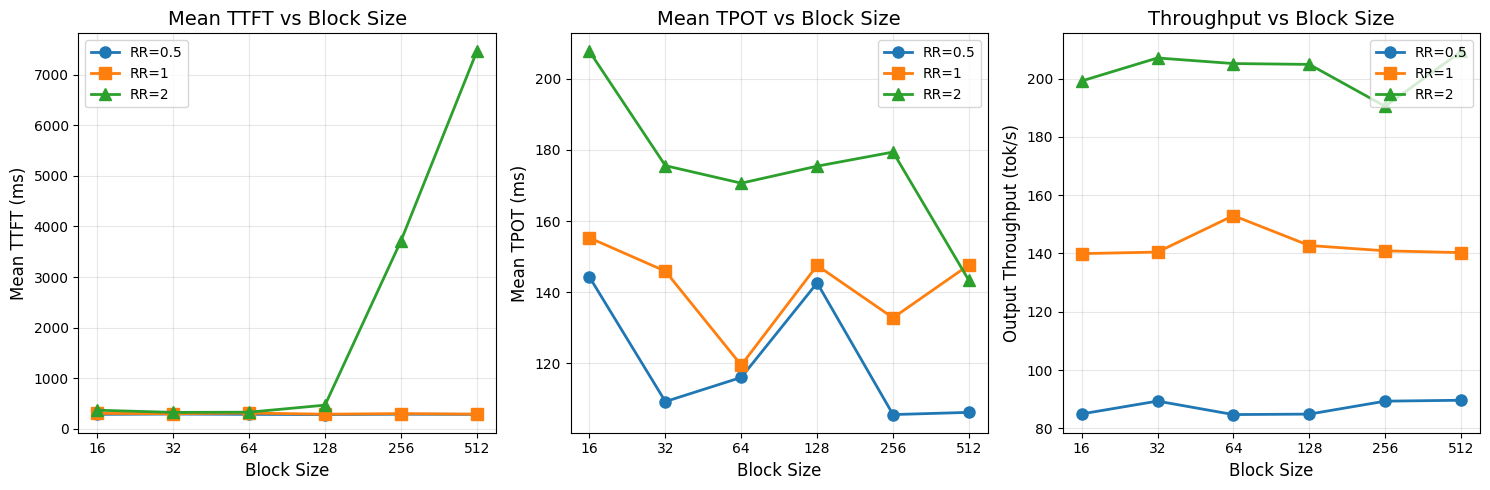

In [2]:
# 绘制三个子图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

# 图1: TTFT Mean
ax1 = axes[0]
for i, rr in enumerate(request_rates):
    df_rr = results_df[results_df['request_rate'] == rr]
    ax1.plot(df_rr['block_size'], df_rr['ttft_mean'], 
             marker=markers[i], color=colors[i], label=f'RR={rr}', linewidth=2, markersize=8)
ax1.set_xlabel('Block Size', fontsize=12)
ax1.set_ylabel('Mean TTFT (ms)', fontsize=12)
ax1.set_title('Mean TTFT vs Block Size', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log', base=2)
ax1.set_xticks(block_sizes)
ax1.set_xticklabels(block_sizes)

# 图2: TPOT Mean
ax2 = axes[1]
for i, rr in enumerate(request_rates):
    df_rr = results_df[results_df['request_rate'] == rr]
    ax2.plot(df_rr['block_size'], df_rr['tpot_mean'], 
             marker=markers[i], color=colors[i], label=f'RR={rr}', linewidth=2, markersize=8)
ax2.set_xlabel('Block Size', fontsize=12)
ax2.set_ylabel('Mean TPOT (ms)', fontsize=12)
ax2.set_title('Mean TPOT vs Block Size', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log', base=2)
ax2.set_xticks(block_sizes)
ax2.set_xticklabels(block_sizes)

# 图3: Throughput
ax3 = axes[2]
for i, rr in enumerate(request_rates):
    df_rr = results_df[results_df['request_rate'] == rr]
    ax3.plot(df_rr['block_size'], df_rr['throughput'], 
             marker=markers[i], color=colors[i], label=f'RR={rr}', linewidth=2, markersize=8)
ax3.set_xlabel('Block Size', fontsize=12)
ax3.set_ylabel('Output Throughput (tok/s)', fontsize=12)
ax3.set_title('Throughput vs Block Size', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xscale('log', base=2)
ax3.set_xticks(block_sizes)
ax3.set_xticklabels(block_sizes)

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/block_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()